[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/26_demand_maintenance.ipynb)

# 📓 Notebook 26 — Demand Forecasting & Predictive Maintenance

The operations double feature. Part I turns NB 11's forecasting craft into **stock orders**: forecast SKU demand, convert forecast error into **safety stock**, and put euros on forecast accuracy with the **newsvendor** trade-off. Part II turns sensor streams into **repair schedules**: predict "fails within 7 days" from telemetry, with the time discipline that NB 24 drilled into you.

> 🧠 **Mental model.** In operations, the forecast itself is worthless — only the *decision* it feeds has value (how much to order, when to service the machine). Both halves of this notebook end in a decision rule with costs attached, not in a MAPE.

## 🎯 Learning objectives

By the end you can:

1. Forecast SKU-level demand three ways — **seasonal-naive**, **Holt-Winters** (NB 11), and **lag-feature regression** that handles promotions — and backtest them honestly.
2. Convert forecast error (σ) into **safety stock** for a target service level, and explain the z-score behind it.
3. Set an order quantity with the **newsvendor** logic: critical ratio = Cu / (Cu + Co).
4. Build a **predictive-maintenance** classifier ("fails within 7 days") from rolling sensor features with a machine-aware, time-aware split.
5. Choose the maintenance alert threshold from **downtime vs false-alarm costs** — the NB 18/41/42 cost logic, third verse.

## ✅ Prerequisites

Notebooks 1–13 and 17–19 (especially NB 11 — Holt-Winters & backtesting, NB 19 — feature pipelines & leakage). Builds on NB 24's time-split discipline. Data generated inline; runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
pd.set_option("display.width", 115)
print("Setup OK")


Setup OK


## Part I — Demand forecasting that ends in a purchase order

### 1. The data: 2 years of daily demand, 3 SKUs, with promotions

A distributor stocks three SKUs of very different character: a steady seller, a weekday-driven B2B item, and a promo-sensitive impulse product. Promotions (~every 6 weeks, 7 days long) multiply demand — and they're *planned*, so future promo dates are known. That makes them a **feature**, not a surprise.

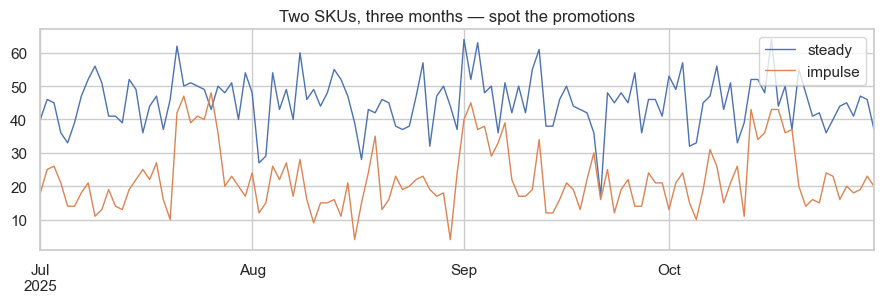

      steady   b2b  impulse
mean    44.3  32.3     21.8
std      8.3  11.8      9.1


In [2]:
days = pd.date_range("2024-01-01", periods=730, freq="D")
t = np.arange(730)
dow = pd.Series(days.dayofweek)

promo = np.zeros(730, dtype=int)
for start in range(21, 730, 42):                      # a 7-day promo every 6 weeks
    promo[start:start + 7] = 1

def make_sku(base, trend, weekly_amp, promo_lift, noise):
    weekly = weekly_amp * np.where(dow < 5, 1.0, -1.2)        # weekday-heavy
    lam = np.clip(base + trend * t + weekly + promo_lift * promo * base, 1, None)
    return rng.poisson(lam + rng.normal(0, noise, 730).clip(-base/2, base/2))

demand = pd.DataFrame({
    "steady":  make_sku(base=40, trend=0.005, weekly_amp=4,  promo_lift=0.15, noise=2),
    "b2b":     make_sku(base=25, trend=0.010, weekly_amp=10, promo_lift=0.05, noise=2),
    "impulse": make_sku(base=18, trend=0.000, weekly_amp=2,  promo_lift=1.10, noise=3),
}, index=days)
demand["promo"] = promo

fig, ax = plt.subplots(figsize=(9, 3.2))
demand.loc["2025-07":"2025-10", ["steady", "impulse"]].plot(ax=ax, lw=1)
ax.set_title("Two SKUs, three months — spot the promotions"); plt.tight_layout(); plt.show()
print(demand[["steady", "b2b", "impulse"]].describe().loc[["mean", "std"]].round(1))


### 2. Three forecasters, one honest backtest

Backtest protocol (NB 11 §11): hold out the **last 8 weeks** and compare MAE. The naive and lag-feature models predict each day from values at least 7 days old (one order cycle); Holt-Winters is fitted once on the training window and projects the whole holdout. The challengers:

1. **Seasonal-naive** — demand = same weekday last week. The baseline every paper and every vendor must beat.
2. **Holt-Winters** — level + trend + weekly seasonality, but *blind to promotions*.
3. **Lag-feature regression** — `.shift` lags (NB 11 §6) wired into NB 19's pipeline thinking: lags (7, 14), day-of-week, and the *known future* promo flag, fed to a gradient-boosted regressor.

### 🔬 What actually happens: turning a time series into a supervised ML problem

The cell below feeds `.shift(7)`, `.shift(14)` and a `promo` flag to a `HistGradientBoostingRegressor`. But a `RandomForest` or a gradient-booster has **no idea what "time" is** — it only knows how to map a *row of features* `X` to a *target* `y`. So how do you "let a tree model forecast"?

The trick — and it's the whole idea behind lag-feature forecasting — is to **reshape the 1-D series into a 2-D (X, y) table**, where:

- each **row's FEATURES are PAST values** of the series (`lag_1` = yesterday, `lag_7` = same day last week, `rolling_mean_3` = the last three days' average), and
- the **TARGET is the value we want to predict** (here: today's demand, given yesterday-and-before).

Once the series wears that table shape, *any* tabular regressor drops straight in. This is called **forecasting-as-supervised-learning**, and `pandas` `.shift()` / `.rolling()` are the two tools that build the table.

> 🧠 **The one sentence to keep.** A forecaster predicts the **next** value from a **window of past** values; `.shift()` slides that window down the column to manufacture "past-as-features", one row per day.

### The sliding window — how `.shift(1)` builds the "yesterday" column

`.shift(1)` moves every value **down one row**, so the number that sat next to today's date is now the value *one step in the past* relative to its new neighbour. Read the diagram column by column — each row pairs **today's target** with the values that were already known **before** that day:

```text
   raw series                lag_1 = series.shift(1)        the supervised row it makes
   (demand y)                ("yesterday")                  features          target
 +------+-----+            +------+-------+                 lag_1            y
 | day  |  y  |            | day  | lag_1 |
 | Mon  | 10  |  shift >   | Mon  |  NaN  |  <- no yesterday  (NaN)     ->     10   dropped
 | Tue  | 12  |  down 1    | Tue  |  10   |                   10       ->     12
 | Wed  | 11  |            | Wed  |  12   |                   12       ->     11
 | Thu  | 15  |            | Thu  |  11   |                   11       ->     15
 | Fri  | 14  |            | Fri  |  15   |                   15       ->     14
 +------+-----+            +------+-------+
                                  |
                the whole y column slid DOWN by one row
```

Add more shifted columns — `lag_7` (`shift(7)`), `rolling_mean_3` (`.rolling(3)`) — and each row grows into a full feature vector describing *the recent past*, paired with *the present* as its target. Train on those rows, and the model learns "given this recent past, the next value tends to be …".

### ⚠️ Why every feature must be a *past* value — the no-peeking rule

Look again at the diagram: the feature on each row is **strictly older** than that row's target. That is not a stylistic choice — it is the rule that keeps the forecast honest:

| If a feature is … | At forecast time you … | Verdict |
|---|---|---|
| `lag_1`, `lag_7` (a **past** value) | already know it — yesterday really has happened | ✅ legitimate |
| today's own `y` (the **target**) | are trying to predict it — you can't use it to predict itself | ❌ leakage |
| a rolling mean that **includes today** | won't have today's full reading at 06:00 when you forecast | ❌ leakage |

A feature that "peeks" at the present or future is **data leakage**: the model scores brilliantly in the notebook and then collapses in production, because the magic number it leaned on simply isn't available yet when the real forecast is due. (You met this exact bug in §6's rolling features — `.rolling(7).mean().shift(1)`, *with* the `.shift(1)` — and Exercise 3 is a whole "Debug me" built around forgetting it.)

> ⚠️ **Two halves of the same rule.** (1) *Features* must use only the past → always `.shift()` a rolling window so today's value can't sneak in. (2) The *train/test split* must respect time → train on early dates, test on later ones, **never** shuffle. That chronological split is exactly what NB 11 and §6's `day < 270` split enforce — same anti-peeking principle, applied to rows instead of columns.

### 🧪 Proof: build the supervised table from a tiny series, offline

No downloads — a 10-day toy demand series in a `DataFrame`. We build `lag_1`, `lag_7`, and `rolling_mean_3` with `.shift()` / `.rolling()`, then print the table so you can read **each row = (past features) → (next value)** with your own eyes.

In [3]:
import numpy as np
import pandas as pd

# A tiny, self-contained daily demand series (no internet, fully reproducible).
dates = pd.date_range("2024-03-01", periods=10, freq="D")
y_demo = pd.Series([10, 12, 11, 15, 14, 9, 8, 13, 16, 12], index=dates, name="demand")

# Reshape the series into a SUPERVISED table: features = PAST, target = the value itself.
sup = pd.DataFrame({
    "demand_today (TARGET)": y_demo,                            # what we want to predict
    "lag_1 (yesterday)":     y_demo.shift(1),                   # value 1 day ago
    "lag_7 (last week)":     y_demo.shift(7),                   # value 7 days ago
    "roll_mean_3 (prev 3d)": y_demo.shift(1).rolling(3).mean(), # avg of the 3 days BEFORE today
})

print("Raw supervised table (note the NaNs at the top — no history yet):")
print(sup.to_string())

Raw supervised table (note the NaNs at the top — no history yet):
            demand_today (TARGET)  lag_1 (yesterday)  lag_7 (last week)  roll_mean_3 (prev 3d)
2024-03-01                     10                NaN                NaN                    NaN
2024-03-02                     12               10.0                NaN                    NaN
2024-03-03                     11               12.0                NaN                    NaN
2024-03-04                     15               11.0                NaN              11.000000
2024-03-05                     14               15.0                NaN              12.666667
2024-03-06                      9               14.0                NaN              13.333333
2024-03-07                      8                9.0                NaN              12.666667
2024-03-08                     13                8.0               10.0              10.333333
2024-03-09                     16               13.0               12.0        

In [4]:
# The first rows have NaN features (the window has nothing to look back at) -> drop them.
ready = sup.dropna()
print("\nAfter dropping warm-up rows (this is what the model actually trains on):")
print(ready.to_string())

# Proof of the no-peeking rule: lag_1 on a row equals the PREVIOUS row's target, exactly.
chk = (ready["lag_1 (yesterday)"].values[1:] == ready["demand_today (TARGET)"].values[:-1])
print("\nlag_1 on each row == previous row's target?", bool(chk.all()),
      "(every feature is a genuine PAST value)")


After dropping warm-up rows (this is what the model actually trains on):
            demand_today (TARGET)  lag_1 (yesterday)  lag_7 (last week)  roll_mean_3 (prev 3d)
2024-03-08                     13                8.0               10.0              10.333333
2024-03-09                     16               13.0               12.0              10.000000
2024-03-10                     12               16.0               11.0              12.333333

lag_1 on each row == previous row's target? True (every feature is a genuine PAST value)


Three things the printout makes concrete:

1. **The window slides.** On `2024-03-08`, `lag_1` = the demand from the 7th and `roll_mean_3` = the mean of the 5th–7th — all values that *had already happened* by the morning of the 8th.
2. **NaNs are warm-up, not errors.** `roll_mean_3` needs 3 prior days, and `lag_7` needs a week of history, so the first rows have no features and are **dropped** (`.dropna()`). You trade a few early rows for a leak-free table — a bargain.
3. **`X` and `y` are now plain columns.** `X = ready[["lag_1 ...", "lag_7 ...", "roll_mean_3 ..."]]`, `y = ready["demand_today ..."]` — feed that pair to `reg.fit(X, y)` and a tree model "forecasts", with no notion of time required.

> 🎯 **Tie it back.** The real cell below builds exactly this kind of table — `pd.DataFrame({"lag7": y.shift(7), "lag14": y.shift(14), "dow": ..., "promo": ...}).dropna()` — then hands `feat` (the `X`) and `target` (the `y`) to `HistGradientBoostingRegressor`. Now you can read every line of it: it is the toy table above, scaled up to two years and three SKUs, with a known-future `promo` flag added as one more (legitimately future-but-*planned*) feature.

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings("ignore")

In [6]:
HOLDOUT = 56
results = {}
for sku in ["steady", "b2b", "impulse"]:
    y = demand[sku]
    train_y, test_y = y[:-HOLDOUT], y[-HOLDOUT:]

    # 1) seasonal-naive: same weekday, previous week
    snaive = y.shift(7)[-HOLDOUT:]

    # 2) Holt-Winters (additive trend + weekly season), refit once on the training window
    hw_fit = ExponentialSmoothing(train_y, trend="add", seasonal="add",
                                  seasonal_periods=7).fit()
    hw_fc = hw_fit.forecast(HOLDOUT)

    # 3) lag features + known promo plan
    feat = pd.DataFrame({"lag7": y.shift(7), "lag14": y.shift(14),
                         "dow": y.index.dayofweek, "promo": demand["promo"]}).dropna()
    target = y.loc[feat.index]
    tr_idx = feat.index[:-HOLDOUT]; te_idx = feat.index[-HOLDOUT:]
    reg = HistGradientBoostingRegressor(max_iter=200, random_state=42)
    reg.fit(feat.loc[tr_idx], target.loc[tr_idx])
    ml_fc = pd.Series(reg.predict(feat.loc[te_idx]), index=te_idx)

    results[sku] = {"seasonal-naive": mean_absolute_error(test_y, snaive),
                    "Holt-Winters":   mean_absolute_error(test_y, hw_fc),
                    "lags+promo ML":  mean_absolute_error(test_y, ml_fc)}

In [7]:
mae = pd.DataFrame(results).round(2)
print("MAE over the 8-week holdout (lower = better):")
print(mae.to_string())

MAE over the 8-week holdout (lower = better):
                steady   b2b  impulse
seasonal-naive   10.30  6.52     9.59
Holt-Winters      5.86  4.94     6.67
lags+promo ML     7.29  5.03     5.43


📊 The same table reads faster as bars — one cluster per SKU, the three forecasters side by side.

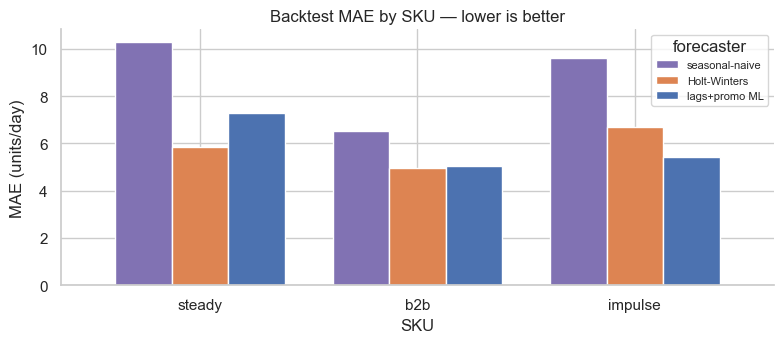

In [8]:
# 📊 Same numbers as the table, grouped so you compare forecasters WITHIN each SKU.
ax = mae.T.plot(kind="bar", figsize=(8, 3.6),
                color=["#8172B3", "#DD8452", "#4C72B0"], width=0.78)
ax.set(title="Backtest MAE by SKU — lower is better", xlabel="SKU", ylabel="MAE (units/day)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="forecaster", fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

---

### ✋ Quick exercise (~2 min) — Lift over the naive baseline

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The MAE table is decisive but raw. For each SKU, turn it into one number a planner cares about: **the % MAE improvement of the best forecaster over the seasonal-naive baseline**. Which SKU gains the most from a smarter model, and why?

In [9]:
# ✍️ Your turn 👇
# Using the `mae` DataFrame, compute for EACH SKU how much the BEST
# (lowest-MAE) model improves on the seasonal-naive baseline, in %.



<details>
<summary>✅ <b>Solution</b></summary>

```python
baseline = mae.loc["seasonal-naive"]
best = mae.min()                      # best (lowest) MAE per SKU column
improvement = (1 - best / baseline) * 100
print(improvement.round(1))
```

The best model beats the naive baseline most on `impulse` (the promo-driven SKU) and least on the smoother SKUs — quantifying NB 11's "beat the baseline or go home", per SKU.
</details>

> 🎯 **Read the table by SKU, not by model.** On *steady* and *b2b*, Holt-Winters already captures the trend and weekly season, and the ML model buys you nothing on top — sometimes it's even slightly worse (NB 11's "beat the baseline or go home" applies to fancy models too). On *impulse*, the regression clearly wins **because promotions are a known future input** that pure time-series models can't see. The general law: model choice follows the *information structure* of the series, not fashion.

### 3. From forecast error to safety stock

You reorder weekly with a 7-day lead time. Demand during that week is uncertain — safety stock is the buffer against that uncertainty:

$$SS = z \cdot \sigma_{\text{lead}} ,\qquad \text{reorder point} = \hat{\mu}_{\text{lead}} + SS$$

where z is the normal quantile of your **service level** (95 % → z = 1.645) and σ is estimated from your *forecast errors* — which is why better forecasts mean less capital tied up in stock.

> 🚫 **Misconception — "A 99% service level is the safe default — just set it high."**
> Safety stock is `z × σ`, and the normal quantile `z` blows up near the tail: z(90%)=1.28, z(95%)=1.64, z(99%)=2.33, z(99.9%)=3.09. The last few points of service level cost **super-linearly** more capital. "Safe" is not free — the right service level comes from the shortage-vs-holding cost trade-off, not from rounding up to 99%.

In [10]:
from scipy import stats

sku = "impulse"
err_ml = (demand[sku][-HOLDOUT:] - pd.Series(reg.predict(feat.loc[te_idx]), index=te_idx))
err_hw = (demand[sku][-HOLDOUT:] - hw_fc)              # hw_fc/reg are from the LAST loop pass = impulse

weekly = pd.DataFrame({
    "sigma_week": [err_hw.std() * np.sqrt(7), err_ml.std() * np.sqrt(7)]},
    index=["Holt-Winters", "lags+promo ML"])
for sl in (0.90, 0.95, 0.99):
    weekly[f"SS@{sl:.0%}"] = (stats.norm.ppf(sl) * weekly["sigma_week"]).round(0)
print(f"Safety stock for '{sku}', one-week protection period:")
print(weekly.round(1).to_string())
UNIT_COST = 6.0
saving = (weekly.loc["Holt-Winters", "SS@95%"] - weekly.loc["lags+promo ML", "SS@95%"]) * UNIT_COST
print(f"\nCapital freed by the better forecast at 95% service: ~{saving:,.0f} EUR for ONE SKU.")


Safety stock for 'impulse', one-week protection period:
               sigma_week  SS@90%  SS@95%  SS@99%
Holt-Winters         23.6    30.0    39.0    55.0
lags+promo ML        17.5    22.0    29.0    41.0

Capital freed by the better forecast at 95% service: ~60 EUR for ONE SKU.


### 🔮 Predict the output

Safety stock is `z(service_level) × σ`. With the *same* demand variability (`σ = 50` units), we step the service level up in **equal 4-point jumps** and print the extra units each jump buys.

```python
from scipy import stats
sigma = 50
levels = [0.90, 0.95, 0.99]
ss = [stats.norm.ppf(p) * sigma for p in levels]
print("90%->95%: +%.0f units" % (ss[1] - ss[0]))
print("95%->99%: +%.0f units" % (ss[2] - ss[1]))
```

Both steps are +4 service points. Does the second jump (95→99) cost about the **same** extra units as the first (90→95), or noticeably **more**?

In [11]:
# Predict first, then run.
from scipy import stats
sigma = 50
for p in (0.90, 0.95, 0.99, 0.999):
    print(f"service {p:>6.1%}  ->  z={stats.norm.ppf(p):.2f}  ->  safety stock {stats.norm.ppf(p)*sigma:5.0f} units")
ss = [stats.norm.ppf(p) * sigma for p in (0.90, 0.95, 0.99)]
print(f"90%->95% costs +{ss[1]-ss[0]:.0f} units;  95%->99% costs +{ss[2]-ss[1]:.0f} units")

service  90.0%  ->  z=1.28  ->  safety stock    64 units
service  95.0%  ->  z=1.64  ->  safety stock    82 units
service  99.0%  ->  z=2.33  ->  safety stock   116 units
service  99.9%  ->  z=3.09  ->  safety stock   155 units
90%->95% costs +18 units;  95%->99% costs +34 units


<details>
<summary>💡 <b>Answer</b></summary>

**The second jump costs much more, even though both add 4 service points.** 90→95% adds about `+18` units (z 1.28→1.64), but 95→99% adds about `+34` units (z 1.64→2.33) — nearly double, for the *same* 4-point gain. And 99→99.9% adds another `+39`. The quantile `z` curves up steeply in the tail, so chasing the last sliver of service level ties up disproportionately more capital. That curvature is exactly why "set it to 99% to be safe" is an expensive default.
</details>

### See the backtest — which forecaster tracks the promo spikes?

The error table is decisive but abstract. Plotting the 56-day holdout for the spiky **impulse** SKU shows *why* one model wins: the lag+promo ML forecaster anticipates the promotion-driven jumps that seasonal-naive and Holt-Winters smear or miss, and that is exactly where the inventory money is won or lost.


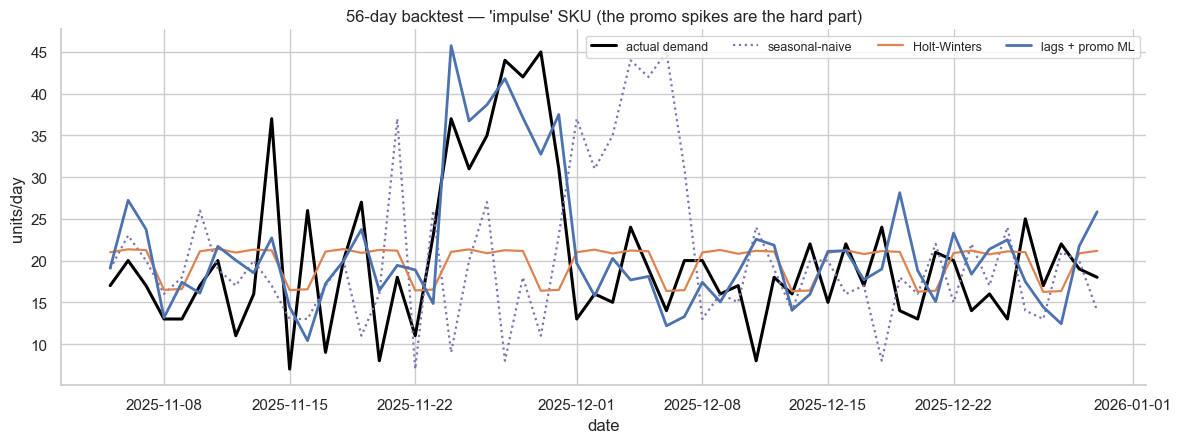

In [12]:
sku = "impulse"
y = demand[sku]
test_y  = y[-HOLDOUT:]
snaive  = y.shift(7)[-HOLDOUT:]
ml_pred = pd.Series(reg.predict(feat.loc[te_idx]), index=te_idx)

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(test_y.index, test_y.values, color="black", lw=2.2, label="actual demand")
ax.plot(snaive.index, snaive.values, color="#8172B3", lw=1.6, ls=":", label="seasonal-naive")
ax.plot(hw_fc.index,  hw_fc.values,  color="#DD8452", lw=1.6, label="Holt-Winters")
ax.plot(ml_pred.index, ml_pred.values, color="#4C72B0", lw=2.0, label="lags + promo ML")
ax.set(title=f"56-day backtest — '{sku}' SKU (the promo spikes are the hard part)",
       xlabel="date", ylabel="units/day")
ax.legend(ncol=4, fontsize=9); sns.despine(); plt.tight_layout(); plt.show()


> 🎛️ **Try it live.** The cell below is interactive in Jupyter/Colab — drag the sliders to feel the trade-off. (It also runs fine without `ipywidgets`; you just get the default values as a static chart.)

In [13]:
# Interactive — needs ipywidgets (preinstalled on Colab; `pip install ipywidgets` locally)
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

def show_safety_stock(service_level=0.95):
    z = stats.norm.ppf(service_level)
    sigma_w = float(err_ml.std() * np.sqrt(7))
    ss_units = z * sigma_w
    ss_eur = ss_units * UNIT_COST
    print(f"service level {service_level:.1%}  ->  z = {z:.2f}")
    print(f"  safety stock = {ss_units:5.0f} units  =  EUR {ss_eur:,.0f} of capital (at EUR{UNIT_COST:.0f}/unit)")
    print(f"  reorder point = mean weekly demand + safety stock")

if _HAS_WIDGETS:
    interact(show_safety_stock,
             service_level=FloatSlider(value=0.95, min=0.80, max=0.995, step=0.005,
                                       description="service", readout_format=".1%"))
else:
    show_safety_stock()

interactive(children=(FloatSlider(value=0.95, description='service', max=0.995, min=0.8, readout_format='.1%',…

### 4. How much to order? The newsvendor in four lines

For perishable or season-bound stock, ordering is a one-shot bet. If being short costs **Cu** per unit (lost margin) and being over costs **Co** (disposal/markdown), the optimal order is the demand quantile at the **critical ratio**:

$$q^* = F^{-1}\!\left(\frac{C_u}{C_u + C_o}\right)$$

> 🎯 **Intuition.** Cu = €4 lost per missed sale, Co = €1 lost per leftover → ratio 0.8 → order the 80th percentile of demand. Expensive shortages push you to over-order; expensive leftovers (fresh food) pull you down. The forecast supplies *F*; economics picks the quantile — **never order the mean**.

In [14]:
Cu, Co = 4.0, 1.0
ratio = Cu / (Cu + Co)
mu_week  = float(pd.Series(reg.predict(feat.loc[te_idx]), index=te_idx).head(7).sum())
sig_week = float(err_ml.std() * np.sqrt(7))
q_star = stats.norm.ppf(ratio, loc=mu_week, scale=sig_week)
print(f"critical ratio = {ratio:.2f} -> order the {ratio:.0%} demand quantile")
print(f"week-ahead demand ~ N({mu_week:.0f}, {sig_week:.0f}) -> order q* = {q_star:.0f} units "
      f"(vs mean {mu_week:.0f})")

# sanity-check by simulation: q* should beat ordering the mean
sim = rng.normal(mu_week, sig_week, 20_000)
def expected_cost(q): return float(np.mean(Cu * np.clip(sim - q, 0, None) + Co * np.clip(q - sim, 0, None)))
print(f"expected cost @mean: {expected_cost(mu_week):,.0f} EUR | @q*: {expected_cost(q_star):,.0f} EUR")


critical ratio = 0.80 -> order the 80% demand quantile
week-ahead demand ~ N(138, 18) -> order q* = 153 units (vs mean 138)
expected cost @mean: 36 EUR | @q*: 25 EUR


📉 The whole newsvendor argument in one curve — expected cost as we sweep the order quantity, with the mean and `q*` marked.

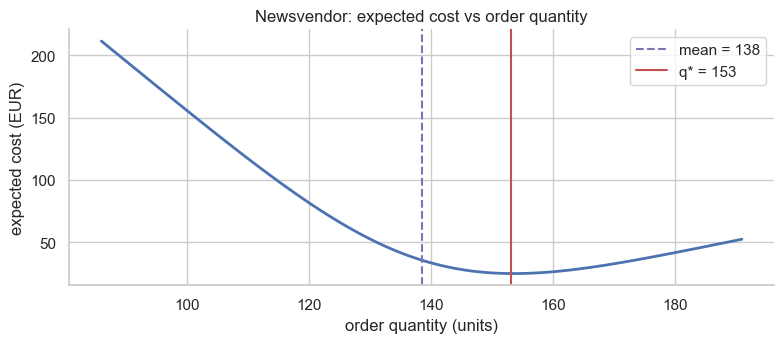

In [15]:
# 📉 Reuse expected_cost() from above across a range of order quantities.
# The minimum sits at q*, not at the mean (ordering the mean over-pays the under-stock penalty).
qs = np.linspace(mu_week - 3 * sig_week, mu_week + 3 * sig_week, 120)
costs = [expected_cost(q) for q in qs]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(qs, costs, color="#4C72B0", lw=2)
ax.axvline(mu_week, color="#8172B3", ls="--", label=f"mean = {mu_week:.0f}")
ax.axvline(q_star,  color="#C44E52", ls="-",  label=f"q* = {q_star:.0f}")
ax.set(title="Newsvendor: expected cost vs order quantity",
       xlabel="order quantity (units)", ylabel="expected cost (EUR)")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

> 🎛️ **Try it live.** The cell below is interactive in Jupyter/Colab — drag the sliders to feel the trade-off. (It also runs fine without `ipywidgets`; you just get the default values as a static chart.)

In [16]:
# Interactive — needs ipywidgets (preinstalled on Colab; `pip install ipywidgets` locally)
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

def show_newsvendor(Cu=4.0, Co=1.0):
    ratio = Cu / (Cu + Co)
    q = stats.norm.ppf(ratio, loc=mu_week, scale=sig_week)
    sim = rng.normal(mu_week, sig_week, 20_000)
    cost_q = float(np.mean(Cu * np.clip(sim - q, 0, None) + Co * np.clip(q - sim, 0, None)))
    cost_mean = float(np.mean(Cu * np.clip(sim - mu_week, 0, None) + Co * np.clip(mu_week - sim, 0, None)))
    print(f"under-stock cost Cu=EUR{Cu:.0f}/unit, over-stock cost Co=EUR{Co:.0f}/unit")
    print(f"  critical ratio = {ratio:.2f}  ->  order the {ratio:.0%} demand quantile")
    print(f"  q* = {q:5.0f} units   (vs ordering the mean = {mu_week:.0f})")
    print(f"  expected cost  @q*: EUR {cost_q:6,.0f}    @mean: EUR {cost_mean:6,.0f}")

if _HAS_WIDGETS:
    interact(show_newsvendor,
             Cu=FloatSlider(value=4.0, min=1, max=20, step=1, description="Cu (short)"),
             Co=FloatSlider(value=1.0, min=1, max=20, step=1, description="Co (over)"))
else:
    show_newsvendor()

interactive(children=(FloatSlider(value=4.0, description='Cu (short)', max=20.0, min=1.0, step=1.0), FloatSlid…

---

### ✋ Quick exercise (~2 min) — Newsvendor for perishables

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

In §4 understocking was the costly side (Cu > Co), so q\* landed *above* the mean. Now flip it: a fresh-food SKU where leftovers spoil, with **Cu = €2** (lost margin) and **Co = €8** (disposal). Recompute the critical ratio and q\* using the same `mu_week` and `sig_week`. Does q\* land above or below the mean?

In [17]:
# ✍️ Your turn 👇
# Fresh food: leftovers spoil. Cu = 2 (lost margin), Co = 8 (disposal).
# Compute the critical ratio and order quantity q* (reuse mu_week, sig_week).
Cu_fresh, Co_fresh = 2.0, 8.0



<details>
<summary>✅ <b>Solution</b></summary>

```python
Cu_fresh, Co_fresh = 2.0, 8.0
ratio = Cu_fresh / (Cu_fresh + Co_fresh)
q_star = stats.norm.ppf(ratio, loc=mu_week, scale=sig_week)
print(f"critical ratio = {ratio:.2f} -> order q* = {q_star:.0f} units (vs mean {mu_week:.0f})")
```

The ratio is 0.20, so q\* sits *below* the mean: when leftovers cost far more than stock-outs, the economics pull the order **down** — the mirror image of the §4 example where shortages dominated.
</details>

### 📊 The same recipe on real demand — UCI Bike Sharing

The synthetic SKUs above let us *plant* a trend, a weekly cycle and promos, so we always knew the answer. Real demand is messier. Here is the **UCI Bike Sharing** dataset — daily bike rentals in Washington D.C. across 2011–2012, with real **weather + calendar** drivers — run through the *same* recipe: build lag features, hold out the tail, and check whether a gradient-boosted model beats the seasonal-naive baseline.

> 📦 Bundled at `data/bike_sharing_daily.csv` (UCI, CC BY 4.0). `cnt` is total daily rentals; `temp`/`hum`/`windspeed` are normalised 0–1 as documented by UCI.

In [18]:
# UCI Bike Sharing (CC BY 4.0): bundled copy if present, else the repo's raw URL
# (so this also runs in Colab).
from pathlib import Path

_bike = next((p for p in [Path("data/bike_sharing_daily.csv"),
                          Path("../data/bike_sharing_daily.csv")] if p.exists()), None)
_BIKE_URL = ("https://raw.githubusercontent.com/ChrisW09/"
             "Python-for-AI-Driven-Automation/main/data/bike_sharing_daily.csv")
bike = pd.read_csv(_bike if _bike else _BIKE_URL, parse_dates=["dteday"])
bike = bike.set_index("dteday").sort_index()

print(f"{len(bike)} days · {bike.index.min().date()} → {bike.index.max().date()}")
bike[["cnt", "temp", "hum", "windspeed", "workingday"]].head()

731 days · 2011-01-01 → 2012-12-31


,cnt,temp,hum,windspeed,workingday
dteday,,,,,
2011-01-01,985,0.344167,0.805833,0.160446,0
2011-01-02,801,0.363478,0.696087,0.248539,0
2011-01-03,1349,0.196364,0.437273,0.248309,1
2011-01-04,1562,0.200000,0.590435,0.160296,1
2011-01-05,1600,0.226957,0.436957,0.186900,1


In [19]:
# Same supervised recipe as the SKUs: lag features + a few real drivers,
# a held-out tail, and a seasonal-naive baseline to beat.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

y = bike["cnt"]
HOLDOUT = 60                                   # last ~2 months as the test tail

feat = pd.DataFrame({
    "lag_1":      y.shift(1),
    "lag_7":      y.shift(7),
    "roll_7":     y.shift(1).rolling(7).mean(),
    "temp":       bike["temp"],
    "hum":        bike["hum"],
    "workingday": bike["workingday"],
    "dow":        bike.index.dayofweek,
}).dropna()
target = y.loc[feat.index]
tr, te = feat.index[:-HOLDOUT], feat.index[-HOLDOUT:]

In [20]:
reg = HistGradientBoostingRegressor(max_iter=300, random_state=42)
reg.fit(feat.loc[tr], target.loc[tr])
pred = pd.Series(reg.predict(feat.loc[te]), index=te)

snaive = y.shift(7).loc[te]                     # baseline: same weekday last week
mae_model  = mean_absolute_error(target.loc[te], pred)
mae_snaive = mean_absolute_error(target.loc[te], snaive)
print(f"Seasonal-naive  MAE : {mae_snaive:,.0f} rentals/day")
print(f"Gradient-boosted MAE: {mae_model:,.0f} rentals/day  "
      f"({(1 - mae_model / mae_snaive):+.0%} vs baseline)")

Seasonal-naive  MAE : 1,489 rentals/day
Gradient-boosted MAE: 947 rentals/day  (+36% vs baseline)


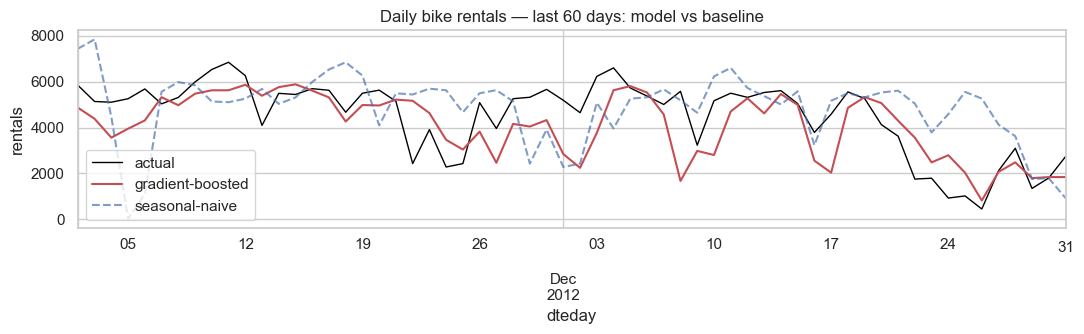

In [21]:
ax = target.loc[te].plot(figsize=(11, 3.5), label="actual", color="black", lw=1)
pred.plot(ax=ax, label="gradient-boosted", color="#C44E52")
snaive.plot(ax=ax, label="seasonal-naive", color="#4C72B0", ls="--", alpha=0.7)
ax.set_title("Daily bike rentals — last 60 days: model vs baseline")
ax.set_ylabel("rentals"); ax.legend(); plt.tight_layout(); plt.show()

## Part II — Predictive maintenance: sensors → repair schedule

### 5. The data: 40 machines, one year of daily telemetry

Each machine reports daily **temperature** and **vibration**. Healthy machines hover around a baseline; in the ~3 weeks before a failure, both drift upward (bearing wear). After a failure the machine is repaired and resets. The prediction target: **will this machine fail within the next 7 days?** — early enough to schedule service, near enough to be actionable.

In [22]:
N_MACH, N_DAYS = 40, 365
m_rng = np.random.default_rng(7)
recs = []
for m in range(N_MACH):
    day_of_fail = []
    nxt = int(m_rng.integers(60, 200))
    while nxt < N_DAYS:
        day_of_fail.append(nxt)
        nxt += int(m_rng.integers(80, 220))
    temp_base, vib_base = m_rng.normal(60, 2), m_rng.normal(1.0, 0.1)
    for d in range(N_DAYS):
        dist = min([f - d for f in day_of_fail if f >= d], default=999)
        wear = max(0.0, 1 - dist / 21) if dist <= 21 else 0.0       # ramps up over final 3 weeks
        recs.append({"machine": m, "day": d,
                     "temp": temp_base + 8 * wear + m_rng.normal(0, 1.0),
                     "vib":  vib_base  + 0.9 * wear + m_rng.normal(0, 0.12),
                     "fails_in_7d": int(0 < dist <= 7)})
tele = pd.DataFrame(recs)
print(tele.head(3))
print(f"\n{N_MACH} machines x {N_DAYS} days = {len(tele):,} rows | positive rate: {tele['fails_in_7d'].mean():.1%}")


   machine  day       temp       vib  fails_in_7d
0        0    0  58.997054  0.791943            0
1        0    1  59.511868  1.071767            0
2        0    2  58.959518  0.836484            0

40 machines x 365 days = 14,600 rows | positive rate: 4.3%


### 6. Rolling features + the split that respects reality

Raw daily readings are noisy; what carries signal is the **trend**: rolling means and the *delta vs the machine's own baseline*. Then the split — by **time** (train on days < 270), exactly like NB 24: in production you predict tomorrow from yesterday's model, never from the future.

> ⚠️ **Pitfall (two leaks in one).** Computing a rolling mean over a window that *includes today's label period*, or letting the same machine-days appear in both sets via a random split — both inflate your offline score and evaporate in production. Rolling features must be **shifted by one day** (yesterday's window predicts today).

In [23]:
tele = tele.sort_values(["machine", "day"]).reset_index(drop=True)
g = tele.groupby("machine")
for col in ("temp", "vib"):
    tele[f"{col}_roll7"]  = g[col].transform(lambda s: s.rolling(7,  min_periods=3).mean().shift(1))
    tele[f"{col}_base"]   = g[col].transform(lambda s: s.expanding().mean().shift(1))
    tele[f"{col}_delta"]  = tele[f"{col}_roll7"] - tele[f"{col}_base"]
    tele[f"{col}_slope7"] = g[f"{col}_roll7"].transform(lambda s: s.diff(7))

MFEATS = ["temp_roll7", "vib_roll7", "temp_delta", "vib_delta", "temp_slope7", "vib_slope7"]
model_df = tele.dropna(subset=MFEATS)
m_train = model_df[model_df["day"] < 270]
m_test  = model_df[model_df["day"] >= 270]

In [24]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score

pm = HistGradientBoostingClassifier(max_iter=250, class_weight={0: 1, 1: 8}, random_state=42)
pm.fit(m_train[MFEATS], m_train["fails_in_7d"])
risk = pm.predict_proba(m_test[MFEATS])[:, 1]
print(f"test rows: {len(m_test):,} | positive (fails-within-7d) rows in test: {m_test['fails_in_7d'].sum()}")
print(f"PR-AUC: {average_precision_score(m_test['fails_in_7d'], risk):.3f} "
      f"(positive rate {m_test['fails_in_7d'].mean():.1%})")

test rows: 3,800 | positive (fails-within-7d) rows in test: 200
PR-AUC: 0.966 (positive rate 5.3%)


🔍 Why does that score beat chance? Healthy days and soon-to-fail days separate on the *delta* features — the rolling average riding above each machine's own baseline.

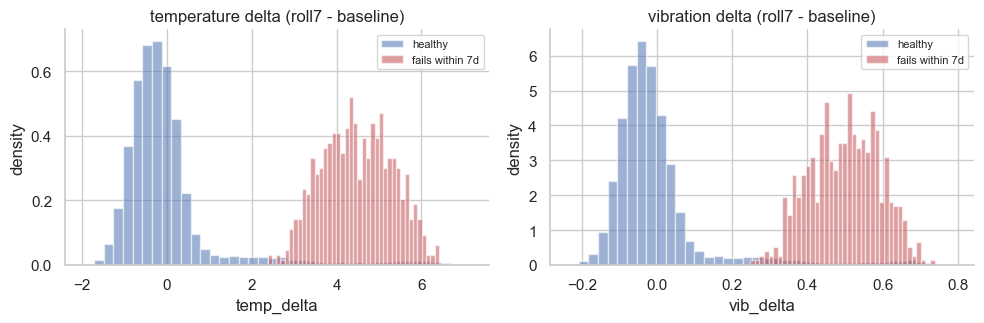

In [25]:
# 🔍 The signal the model keys on: on days that precede a failure, the rolling
# average rides ABOVE each machine's own baseline (delta > 0).
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, col, label in zip(axes, ["temp_delta", "vib_delta"], ["temperature", "vibration"]):
    for cls, color, name in [(0, "#4C72B0", "healthy"), (1, "#C44E52", "fails within 7d")]:
        ax.hist(model_df.loc[model_df["fails_in_7d"] == cls, col],
                bins=40, density=True, alpha=0.55, color=color, label=name)
    ax.set(title=f"{label} delta (roll7 - baseline)", xlabel=col, ylabel="density")
    ax.legend(fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

---

### ✋ Quick exercise (~2 min) — Read the model at the default cutoff

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

PR-AUC summarizes the whole curve, but operations acts at a *threshold*. Using the `risk` scores and `m_test["fails_in_7d"]`, at the textbook **0.5** cutoff compute (a) how many machine-days get flagged and (b) the **precision** among flagged days (share that actually failed). Keep the number in mind — §7 is about to move this threshold.

In [26]:
# ✍️ Your turn 👇
# Using `risk` and m_test["fails_in_7d"], at a textbook 0.5 cutoff:
# how many machine-days are flagged, and what share of them truly failed (precision)?



<details>
<summary>✅ <b>Solution</b></summary>

```python
flagged = risk > 0.5
n_flag = int(flagged.sum())
precision = m_test["fails_in_7d"].to_numpy()[flagged].mean()
print(f"flagged at 0.5: {n_flag} machine-days | precision: {precision:.1%}")
```

At the textbook 0.5 cutoff the model is conservative — few alerts, high precision, but it lets failures slip through. §7 shows why 0.5 is the *wrong* cutoff once you price a missed failure against a false alarm.
</details>

### 7. The maintenance decision — third verse of the cost song

A **false alarm** sends a technician for nothing: €150. A **missed failure** stops the line: €2,500. So alert when `p × 2500 > 150`, i.e. above p\* = 6 % — *not* at 0.5. (NB 18 set up this logic, NB 23 priced retention with it, NB 24 staffed a queue with it. Operations runs on one idea, well-worn.)

In [27]:
C_ALARM, C_MISS = 150.0, 2500.0
p_star = C_ALARM / C_MISS
alerts = risk > p_star
tp = int(((alerts) & (m_test["fails_in_7d"] == 1)).sum())
fp = int(((alerts) & (m_test["fails_in_7d"] == 0)).sum())
fn = int(((~alerts) & (m_test["fails_in_7d"] == 1)).sum())
cost_model  = fp * C_ALARM + fn * C_MISS
cost_never  = int(m_test["fails_in_7d"].sum()) * C_MISS
print(f"alert threshold p* = {p_star:.0%}")
print(f"alerts: {alerts.sum():>4} | caught: {tp} | false alarms: {fp} | missed: {fn}")
print(f"cost with model: {cost_model:>10,.0f} EUR")
print(f"cost run-to-failure (never alert): {cost_never:>10,.0f} EUR")


alert threshold p* = 6%
alerts:  266 | caught: 196 | false alarms: 70 | missed: 4
cost with model:     20,500 EUR
cost run-to-failure (never alert):    500,000 EUR


---

### ✋ Quick exercise (~2 min) — Re-price the alert threshold

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The threshold p\* = C_ALARM / C_MISS is a lever, not a constant. Suppose the line becomes mission-critical and a **missed failure now costs €5,000** (the false-alarm cost stays €150). Recompute p\* and count how many alerts it triggers on the test set with the same `risk` scores. Does the model alert more or less often?

In [28]:
# ✍️ Your turn 👇
# The line is now mission-critical: a missed failure costs EUR 5,000.
# Recompute the optimal threshold p* and how many alerts it triggers on the test set.
C_MISS_NEW = 5000.0



<details>
<summary>✅ <b>Solution</b></summary>

```python
C_MISS_NEW = 5000.0
p_star_new = C_ALARM / C_MISS_NEW
alerts_new = risk > p_star_new
print(f"new p* = {p_star_new:.1%} | alerts: {int(alerts_new.sum())} (was {int((risk > p_star).sum())} at p*={p_star:.0%})")
```

Doubling the miss cost halves p\* (6% → 3%), lowering the bar to alert, so the model fires **more** often — fewer expensive misses. The threshold tracks the cost ratio, never the default 0.5.
</details>

### 8. What real maintenance programs add (honest section)

- **Remaining useful life (RUL)** regression and **survival models** replace the binary 7-day window when you need *scheduling*, not just *alarming*.
- **Per-machine thresholds** — a sensor baseline differs per machine; our `_delta` features handle the mean shift, fleets with heterogeneous duty cycles need more.
- **Alert fatigue is the killer.** A model that cries wolf gets unplugged by the night shift, whatever its PR-AUC. The €150 above is really "€150 + eroded trust".
- **The feedback trap returns:** if technicians fix every flagged machine, you never observe the failure you prevented — NB 24's selective labels, in overalls.

---


## 🧠 The story in one screen

Both halves of this double feature began with a number and ended in a **decision with euros on it** — never a MAPE, never a PR-AUC.

**Part I — demand → a purchase order:**
1. Three forecasters, one honest backtest: the lesson wasn't "ML wins" but *model choice follows the information structure of the series* — Holt-Winters ties on steady SKUs, regression wins on `impulse` because **planned promotions are a known future feature**.
2. Forecast error became **safety stock** (`SS = z·σ`), so a better forecast literally frees up capital.
3. The **newsvendor** put a price on the order itself: order the demand quantile at `Cu / (Cu + Co)` — *never the mean*.

**Part II — sensors → a repair schedule:**
4. Telemetry plus *time-respecting* rolling features (every column a past value — the no-peeking rule from NB 24, in overalls) predicted "fails within 7 days."
5. The alert threshold came from the **cost matrix** — €150 false alarm vs €2,500 missed failure → act above 6 %, not 0.5 — and capacity turned scores into a *ranked work-order list*.

> 🧭 **Mental model, one last time.** This was the **third verse of the cost song**: NB 23 priced retention, NB 24 staffed a fraud queue, NB 26 sized stock orders and repair schedules — *same idea, three costumes.* In operations the forecast or score is worthless on its own; value lives only in the **decision rule with costs attached** that it feeds. Master that one move and you've mastered all four notebooks in this module.


## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ MAPE's dirty secret
Compute MAPE and MAE for the seasonal-naive forecast on `steady` and on `impulse` (holdout window). Then explain: why does comparing *MAPE across SKUs* mislead here, and which single change to the denominator fixes most of it? (Implement WAPE = Σ|err| / Σ demand.)

In [29]:
# Starter
# mape = (abs(err) / actual).mean() * 100


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
for sku in ("steady", "impulse"):
    y = demand[sku]; actual = y[-HOLDOUT:]; fc = y.shift(7)[-HOLDOUT:]
    err = actual - fc
    mape = float((err.abs() / actual).mean() * 100)
    wape = float(err.abs().sum() / actual.sum() * 100)
    print(f"{sku:>8}: MAE {err.abs().mean():5.1f} | MAPE {mape:5.1f}% | WAPE {wape:5.1f}%")
```

**Why this works:** MAPE divides each day's error by *that day's* demand, so low-demand days (impulse's non-promo weekends) explode the percentage even when absolute errors are small — and a few near-zero days can dominate the average. WAPE weights by volume (one division by *total* demand), which is why supply-chain teams quote WAPE/forecast-accuracy instead. Metric choice is a business decision here too.
</details>

### Exercise 2 — ⭐⭐ Service level vs capital, the trade-off curve
For the `impulse` SKU with the ML forecast errors, compute safety stock and its carrying value (€6/unit) for service levels 85–99.5 %. Plot € against service level. Where does the curve go vertical, and what question should you ask the business at that point?

In [30]:
# Starter
# levels = np.arange(0.85, 0.996, 0.005)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
levels = np.arange(0.85, 0.996, 0.005)
sigma_w = float(err_ml.std() * np.sqrt(7))
ss_eur = stats.norm.ppf(levels) * sigma_w * UNIT_COST
plt.figure(figsize=(6.5, 3))
plt.plot(levels * 100, ss_eur, lw=2)
plt.xlabel("service level (%)"); plt.ylabel("safety-stock capital (EUR)")
plt.title("The last percentage points are the expensive ones")
plt.tight_layout(); plt.show()
print(f"95 -> 99%: +{(stats.norm.ppf(0.99)-stats.norm.ppf(0.95))*sigma_w*UNIT_COST:,.0f} EUR; "
      f"99 -> 99.5%: +{(stats.norm.ppf(0.995)-stats.norm.ppf(0.99))*sigma_w*UNIT_COST:,.0f} EUR")
```

**Why this works:** safety stock scales with the normal quantile, which grows *super-linearly* as the service level approaches 1 — the curve's vertical tail is `ppf` heading to infinity. The question to ask: *"which stock-outs actually cost us Cu?"* — a blanket 99 % service level on every SKU is how warehouses fill with capital; the newsvendor ratio (§4) gives each SKU the service level its economics deserve.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: The forecaster that knew too much
The cell below trains a maintenance model that scores about as well as our careful one — tempting to ship the simpler pipeline. But one detail means it could never run in production. Find the leak (it's in the features): *when* is each feature value actually known?

In [31]:
# A 'great' model — runs fine, evaluates great. Where is the leak?
leaky = tele.copy()
gl = leaky.groupby("machine")
leaky["temp_roll7_leak"] = gl["temp"].transform(lambda s: s.rolling(7, min_periods=3).mean())  # no shift!
leaky["vib_roll7_leak"]  = gl["vib"].transform(lambda s: s.rolling(7, min_periods=3).mean())   # no shift!
LFEATS = ["temp_roll7_leak", "vib_roll7_leak"]
ld = leaky.dropna(subset=LFEATS)
l_tr, l_te = ld[ld["day"] < 270], ld[ld["day"] >= 270]
lm = HistGradientBoostingClassifier(max_iter=150, class_weight={0: 1, 1: 8}, random_state=42)
lm.fit(l_tr[LFEATS], l_tr["fails_in_7d"])
print(f"PR-AUC: {average_precision_score(l_te['fails_in_7d'], lm.predict_proba(l_te[LFEATS])[:, 1]):.3f}  ← looks fine, and ~tied with the honest model; the bug is *when* the feature is known (see solution)")


PR-AUC: 0.587  ← looks fine, and ~tied with the honest model; the bug is *when* the feature is known (see solution)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# The leak: rolling(7).mean() WITHOUT .shift(1) includes TODAY's reading in today's feature.
# The labels cover "fails within the NEXT 7 days", and wear ramps up as failure approaches —
# so today's reading carries tomorrow's wear signal. At scoring time ("alert me at 06:00 for
# the coming week"), today's full day of data doesn't exist yet.
fixed = tele.copy()
gf = fixed.groupby("machine")
fixed["temp_roll7_ok"] = gf["temp"].transform(lambda s: s.rolling(7, min_periods=3).mean().shift(1))
fixed["vib_roll7_ok"]  = gf["vib"].transform(lambda s: s.rolling(7, min_periods=3).mean().shift(1))
FF = ["temp_roll7_ok", "vib_roll7_ok"]
fd = fixed.dropna(subset=FF)
f_tr, f_te = fd[fd["day"] < 270], fd[fd["day"] >= 270]
fm = HistGradientBoostingClassifier(max_iter=150, class_weight={0: 1, 1: 8}, random_state=42)
fm.fit(f_tr[FF], f_tr["fails_in_7d"])
print(f"honest PR-AUC: {average_precision_score(f_te['fails_in_7d'], fm.predict_proba(f_te[FF])[:, 1]):.3f}")
```

**Why this works:** the one-day shift looks pedantic and is everything: features must be computable strictly *before* the prediction moment. The unshifted version isn't "a bit optimistic" — it changes what the model learns (it rewards reading the freshest wear signal instead of anticipating it). Same disease as NB 23's refund column and NB 24's random split; in time-series feature engineering, `.shift(1)` is the vaccination.
</details>

### Exercise 4 — ⭐⭐ Tune the alert threshold from the cost matrix
Sweep the maintenance alert threshold from 1 % to 50 % and compute the total cost (€150 per false alarm, €2,500 per miss) on the test window. Plot cost vs threshold, mark the analytic p* = 6 %, and explain any gap between the analytic and the empirical optimum.

In [32]:
# Starter
# for thr in np.arange(0.01, 0.51, 0.01): ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
thrs = np.arange(0.01, 0.51, 0.01)
costs = []
yv = m_test["fails_in_7d"].to_numpy()
for thr in thrs:
    a = risk > thr
    costs.append(int(((a) & (yv == 0)).sum()) * C_ALARM + int(((~a) & (yv == 1)).sum()) * C_MISS)
plt.figure(figsize=(6.5, 3))
plt.plot(thrs * 100, costs, lw=2); plt.axvline(p_star * 100, ls="--", color="#dd8452")
plt.xlabel("alert threshold (%)"); plt.ylabel("total cost (EUR)")
plt.tight_layout(); plt.show()
best = float(thrs[int(np.argmin(costs))])
print(f"analytic p* = {p_star:.0%} | empirical best = {best:.0%} | cost there = {min(costs):,.0f} EUR")
```

**Why this works:** the analytic p* is optimal only if the predicted probabilities are **calibrated**; gradient boosting's raw scores usually aren't, so the empirical minimum sits at a different cutoff. Two valid fixes: calibrate the model (NB 23 Stretch A) and keep the clean theory, or skip calibration and tune the threshold empirically on a validation window, as done here. Doing *neither* — trusting p* on uncalibrated scores — is the common mistake.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐ How much is each promo worth?
Estimate the promo lift on `impulse` two ways: (a) naive — mean demand on promo days ÷ mean on non-promo days; (b) adjusted — same-weekday comparison (promo vs non-promo means *per weekday*, then averaged). Why do they differ, and which would you put in the marketing deck?

In [33]:
# Starter
# promo_days = demand[demand["promo"] == 1] ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
naive = demand.loc[demand["promo"] == 1, "impulse"].mean() / \
        demand.loc[demand["promo"] == 0, "impulse"].mean()

per_dow = demand.assign(dow=demand.index.dayofweek).groupby(["dow", "promo"])["impulse"].mean().unstack()
adjusted = (per_dow[1] / per_dow[0]).mean()
print(f"naive lift: x{naive:.2f} | weekday-adjusted lift: x{adjusted:.2f}")
```

**Why this works:** promo windows don't fall uniformly across weekdays, and `impulse` has (mild) weekday structure — the naive ratio mixes the promo effect with the day-mix effect. Stratifying by weekday and *then* averaging removes that confounder: a first taste of causal adjustment with nothing but `groupby`. The adjusted number goes in the deck; the gap between the two goes in your mental file labelled "why averages lie" (Capstone A's Simpson's-paradox demo — NB 47 — is the grown-up version).
</details>

### Stretch exercise B — ⭐⭐⭐ Forecast the total, or sum the parts?
The warehouse orders *total* units across the three SKUs. Compare (a) summing the three per-SKU seasonal-naive forecasts vs (b) forecasting the summed series directly, on the holdout MAE. Which wins, and what does that imply for a 5,000-SKU hierarchy?

In [34]:
# Starter
# total = demand[["steady", "b2b", "impulse"]].sum(axis=1)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
total = demand[["steady", "b2b", "impulse"]].sum(axis=1)
actual = total[-HOLDOUT:]

bottom_up = (demand["steady"].shift(7) + demand["b2b"].shift(7) + demand["impulse"].shift(7))[-HOLDOUT:]
direct    = total.shift(7)[-HOLDOUT:]
print(f"bottom-up MAE: {(actual - bottom_up).abs().mean():.1f}")
print(f"direct    MAE: {(actual - direct).abs().mean():.1f}")
```

**Why this works:** with seasonal-naive the two are *identical by construction* (the sum of shifts equals the shift of sums) — a tiny proof that the question only becomes real for non-linear models. There, aggregates are smoother (errors partially cancel → easier to forecast directly), while bottom-up gives SKU detail the warehouse needs for picking. Real systems forecast *both* levels and **reconcile** them (MinT and friends); appendix `A2_forecasting_prophet_libraries` shows libraries that do this for you.
</details>

### Stretch exercise C — ⭐⭐⭐ Lead-time uncertainty enters the chat
§3 assumed the lead time is exactly 7 days. Suppose it's normal with μ=7, σ=2 (supplier wobble). The proper σ for protection-period demand becomes
$$\sigma_{\text{prot}} = \sqrt{\mu_L\,\sigma_d^2 + \bar d^{\,2}\,\sigma_L^2}$$
with daily demand mean d̄ and σ_d. Compute both terms for `impulse` and report how much extra safety stock supplier wobble costs at 95 %.

In [35]:
# Starter — daily stats from the ML residuals + demand series.


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
d_bar   = float(demand["impulse"][-HOLDOUT:].mean())
sigma_d = float(err_ml.std())
mu_L, sigma_L = 7.0, 2.0

term_demand = mu_L * sigma_d**2
term_lead   = d_bar**2 * sigma_L**2
sigma_prot  = np.sqrt(term_demand + term_lead)

z = stats.norm.ppf(0.95)
ss_fixed = z * sigma_d * np.sqrt(mu_L)
ss_full  = z * sigma_prot
print(f"demand-uncertainty term: {term_demand:,.0f} | lead-time term: {term_lead:,.0f}")
print(f"SS, fixed lead time: {ss_fixed:,.0f} units | with lead-time wobble: {ss_full:,.0f} units")
print(f"extra capital: {(ss_full - ss_fixed) * UNIT_COST:,.0f} EUR for this one SKU")
```

**Why this works:** protection-period demand is a *random sum* of random variables, and its variance decomposes into "demand varies" + "the window length varies". The second term scales with **d̄²**, so for high-volume SKUs supplier reliability dominates forecast quality — a result that regularly redirects projects: the cheapest "forecasting" win is sometimes a contract clause about delivery windows, not a better model.
</details>

### Stretch exercise D — ⭐⭐⭐ From alarm to schedule: cumulative failure curves
Group test-set machine-days into risk deciles. For each decile, plot the *observed* share that failed within 7 days (a calibration-by-decile curve). Then answer the planner's actual question: if you can service **3 machines per week**, which decile boundary should trigger scheduling, and how many failures per month does that policy prevent?

In [36]:
# Starter
# deciles = pd.qcut(risk, 10, labels=False) ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
dec = pd.qcut(risk, 10, labels=False, duplicates="drop")
obs = pd.DataFrame({"decile": dec, "failed": m_test["fails_in_7d"].to_numpy()}) \
        .groupby("decile")["failed"].agg(["mean", "size"])
print(obs.rename(columns={"mean": "observed_7d_failure_rate", "size": "machine_days"}).round(3).to_string())

# capacity: 3 services/week over the ~14 test weeks -> 42 machine-slots; pick from the top
cap = 3 * int(np.ceil((365 - 270) / 7))
order_idx = np.argsort(-risk)
sched = order_idx[:cap]
prevented = int(m_test["fails_in_7d"].to_numpy()[sched].sum())
per_month = prevented / ((365 - 270) / 30)
print(f"\nservice capacity {cap} machine-slots -> failures pre-empted: {prevented} (~{per_month:.1f}/month)")
```

**Why this works:** the decile table is calibration made digestible — "decile 10 fails 30× more often than decile 1" is a sentence a maintenance planner acts on. And capacity-first scheduling closes the loop this notebook promised: the model produces a *ranked work order list under a constraint*, the same shape as NB 24's alert queue and NB 23's campaign list. Operations ML is one pattern with three costumes.
</details>

## 🎁 Bonus mini-project — the Monday S&OP one-pager

Write `sop_report()` that produces one markdown page: per-SKU 7-day forecast with the chosen model, recommended order quantities (newsvendor where Cu/Co differ per SKU — invent sensible costs), current safety-stock levels at 95 %, the week's maintenance schedule (top-3 machines by risk with their decile failure rates), and one drift flag (this week's forecast error vs the backtest σ). Numbers from this notebook, prose from NB 28 if you want it, scheduling from NB 46 when it should run itself every Monday at 06:00.

## ✅ Self-assessment checklist

- [ ] I always benchmark against seasonal-naive and can say *per SKU* whether complexity paid.
- [ ] I can explain why known promotions make regression-with-lags beat pure time-series models.
- [ ] I can size safety stock from forecast errors and defend the service level with the cost curve.
- [ ] I can state the newsvendor critical ratio and why ordering the mean is wrong.
- [ ] My rolling features are shifted; my splits respect time and machine; I caught the leak in Ex. 3.
- [ ] I can turn model scores into a capacity-constrained schedule and quantify what it prevents.

## 🚀 Next step

Module 7 complete — you've now seen the four costumes industry ML wears most. If you haven't yet: **Module 8 — AI Engineering** (`../08_ai_engineering/28_ai_workflows.ipynb`) shows what LLMs add on top, and **Capstone A** (`../15_capstones/47_capstone_analytics.ipynb`) is where you prove the analytics half end-to-end. If you've done both: take one notebook from this module and rebuild it on *your* company's data. That's the real capstone.